In [1]:
import sys

print(sys.executable)

/usr/local/bin/python3


## IMPORT LIBRARIES

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)
print(tf.__version__)

2.21.0


In [4]:
dataset_path = "/Users/manimaranjb/Downloads/solar_project/Faulty_solar_panel"

In [5]:
os.listdir(dataset_path)

['.DS_Store',
 'Physical-Damage',
 'Dusty',
 'Snow-Covered',
 'Clean',
 'Electrical-damage',
 'Bird-drop']

#### Remove .DS_Store

In [6]:
classes = [
    folder for folder in os.listdir(dataset_path)
    if not folder.startswith(".")
]

classes

['Physical-Damage',
 'Dusty',
 'Snow-Covered',
 'Clean',
 'Electrical-damage',
 'Bird-drop']

#### Check Folder Structure

In [7]:
for cls in classes:
    print(cls, "->", len(os.listdir(os.path.join(dataset_path, cls))))

Physical-Damage -> 69
Dusty -> 190
Snow-Covered -> 123
Clean -> 193
Electrical-damage -> 103
Bird-drop -> 192


#### Store Clean Class Names

In [8]:
class_names = classes

print(class_names)

['Physical-Damage', 'Dusty', 'Snow-Covered', 'Clean', 'Electrical-damage', 'Bird-drop']


### Data Cleaning & Dataset Analysis

In [10]:
### Count Images Per Class

class_counts = {}

for cls in classes:

    folder_path = os.path.join(
        dataset_path,
        cls
    )

    image_count = len(
        [
            img for img in os.listdir(folder_path)
            if img.lower().endswith(
                (".jpg", ".jpeg", ".png")
            )
        ]
    )

    class_counts[cls] = image_count


class_counts

{'Physical-Damage': 69,
 'Dusty': 190,
 'Snow-Covered': 123,
 'Clean': 193,
 'Electrical-damage': 103,
 'Bird-drop': 191}

In [11]:
#### Convert Count to DataFrame

class_df = pd.DataFrame(
    list(class_counts.items()),
    columns=[
        "Class",
        "Image_Count"
    ]
)

class_df

,Class,Image_Count
0,Physical-Damage,69
1,Dusty,190
2,Snow-Covered,123
3,Clean,193
4,Electrical-damage,103
5,Bird-drop,191


In [12]:
#### Check Image File Extensions

extensions = {}

for cls in classes:

    folder_path = os.path.join(
        dataset_path,
        cls
    )

    for img in os.listdir(folder_path):

        ext = os.path.splitext(img)[1].lower()

        if ext in extensions:
            extensions[ext] += 1
        else:
            extensions[ext] = 1


extensions

{'.jpg': 861, '.png': 5, '.jpeg': 3, '': 1}

In [13]:
#### Find Corrupted Images

corrupted_images = []


for cls in classes:

    folder_path = os.path.join(
        dataset_path,
        cls
    )

    for img_name in os.listdir(folder_path):

        if img_name.lower().endswith(
            (".jpg",".jpeg",".png")
        ):

            img_path = os.path.join(
                folder_path,
                img_name
            )

            try:

                img = Image.open(img_path)

                img.verify()

            except:

                corrupted_images.append(
                    img_path
                )


corrupted_images

[]

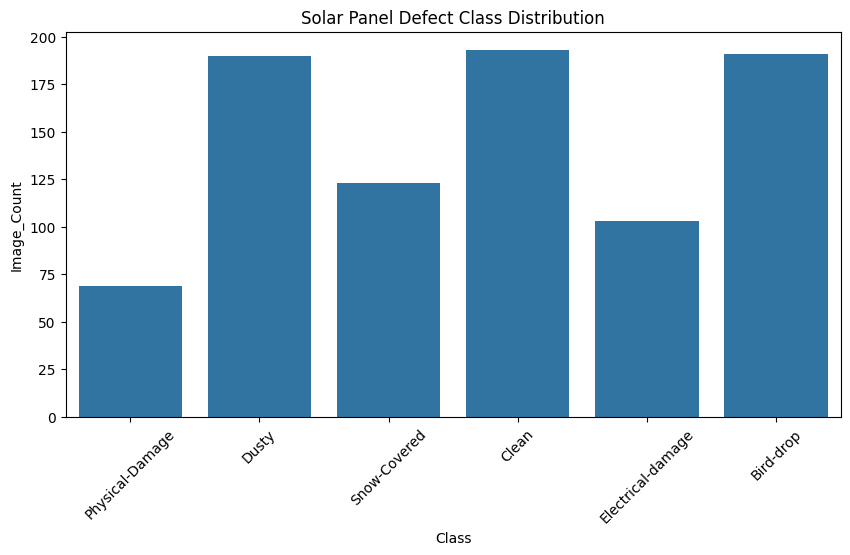

In [14]:
#### Visualize Class Distribution

plt.figure(figsize=(10,5))


sns.barplot(

    data=class_df,

    x="Class",

    y="Image_Count"

)


plt.xticks(rotation=45)


plt.title(
    "Solar Panel Defect Class Distribution"
)


plt.show()

## Exploratory Data Analysis (EDA)

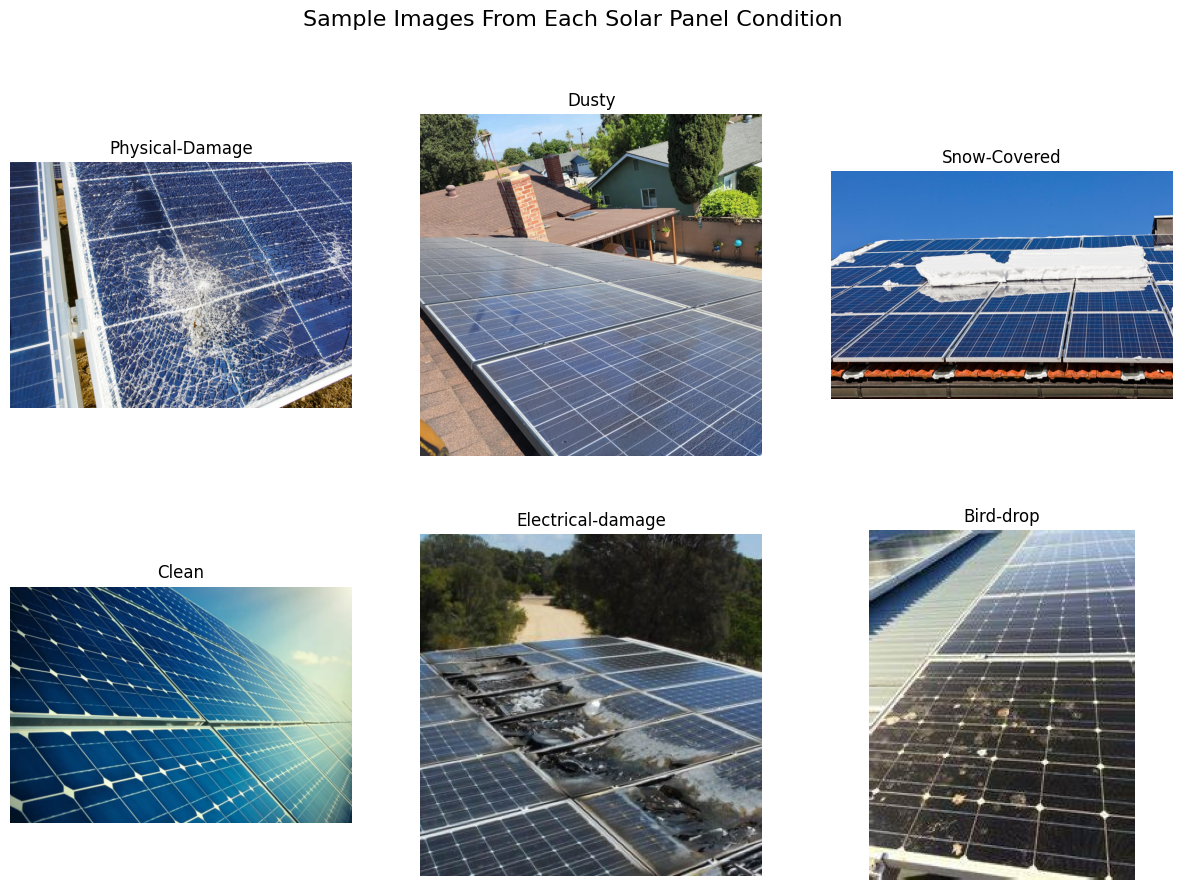

In [15]:
# Display Random Images From Each Class

import random

plt.figure(figsize=(15,10))


for i, cls in enumerate(classes):

    folder_path = os.path.join(
        dataset_path,
        cls
    )

    images = [
        img for img in os.listdir(folder_path)
        if img.lower().endswith(
            (".jpg",".jpeg",".png")
        )
    ]

    random_image = random.choice(images)


    img_path = os.path.join(
        folder_path,
        random_image
    )


    img = Image.open(img_path)


    plt.subplot(2,3,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")


plt.suptitle(
    "Sample Images From Each Solar Panel Condition",
    fontsize=16
)


plt.show()

In [16]:
# Analyze Image Dimensions

image_sizes = []


for cls in classes:

    folder_path = os.path.join(
        dataset_path,
        cls
    )


    images = [
        img for img in os.listdir(folder_path)
        if img.lower().endswith(
            (".jpg",".jpeg",".png")
        )
    ]


    for img_name in images[:50]:

        img_path = os.path.join(
            folder_path,
            img_name
        )


        img = Image.open(img_path)


        image_sizes.append(
            img.size
        )


image_sizes[:10]

[(768, 1024),
 (3024, 4032),
 (1536, 2048),
 (474, 316),
 (474, 228),
 (768, 512),
 (1024, 768),
 (370, 160),
 (406, 406),
 (430, 700)]

In [17]:
# Image Width and Height Distribution

size_df = pd.DataFrame(
    image_sizes,
    columns=[
        "Width",
        "Height"
    ]
)


size_df.head()

,Width,Height
0,768,1024
1,3024,4032
2,1536,2048
3,474,316
4,474,228


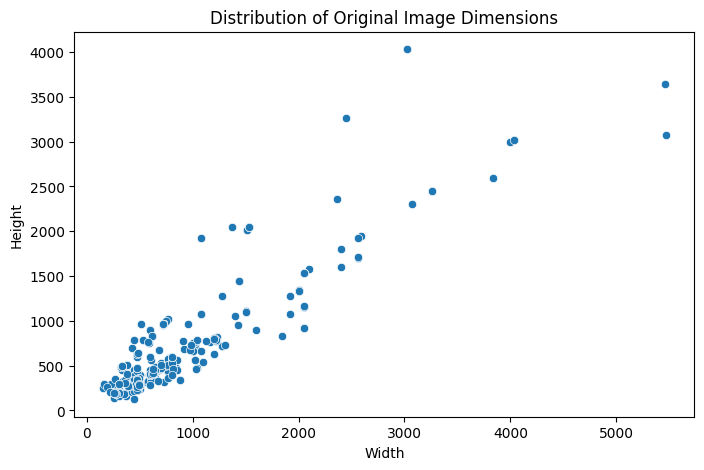

In [18]:
plt.figure(figsize=(8,5))


sns.scatterplot(
    data=size_df,
    x="Width",
    y="Height"
)


plt.title(
    "Distribution of Original Image Dimensions"
)


plt.show()

In [19]:
# Average Image Size

print(
    "Average Width:",
    int(size_df["Width"].mean())
)


print(
    "Average Height:",
    int(size_df["Height"].mean())
)

Average Width: 945
Average Height: 761


In [20]:
# Pixel Intensity Analysis

pixel_values=[]


for cls in classes:

    folder_path=os.path.join(
        dataset_path,
        cls
    )


    images=[
        img for img in os.listdir(folder_path)
        if img.lower().endswith(
            (".jpg",".jpeg",".png")
        )
    ]


    img_path=os.path.join(
        folder_path,
        images[0]
    )


    img=Image.open(img_path).convert("RGB")


    img_array=np.array(img)


    pixel_values.append(
        img_array.mean()
    )


pixel_values

[np.float64(114.75914594862196),
 np.float64(124.87829647508924),
 np.float64(114.8981951629729),
 np.float64(109.53264916818175),
 np.float64(130.59179445546937),
 np.float64(120.22436758384343)]

In [ ]:
# Create dataframe

pixel_df=pd.DataFrame({

    "Class":classes,

    "Average_Pixel_Intensity":pixel_values

})


pixel_df

,Class,Average_Pixel_Intensity
0,Physical-Damage,114.759146
1,Dusty,124.878296
2,Snow-Covered,114.898195
3,Clean,109.532649
4,Electrical-damage,130.591794
5,Bird-drop,120.224368


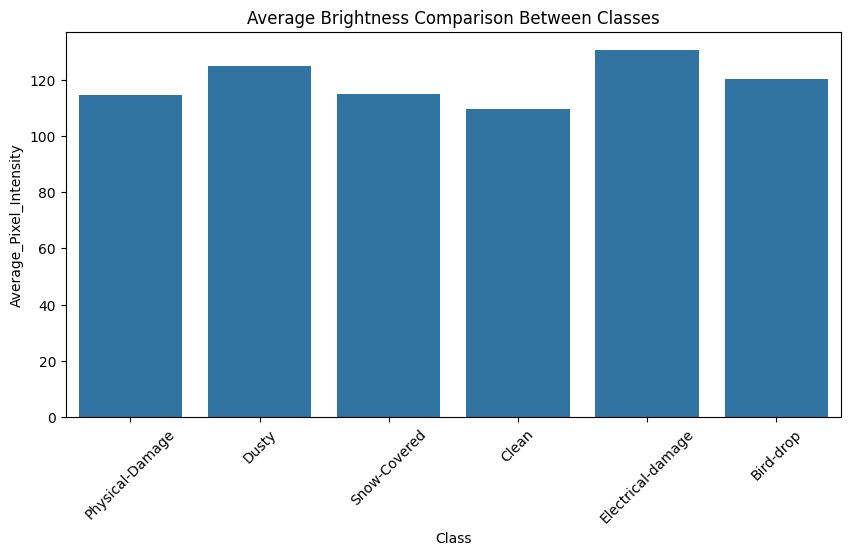

In [22]:
# Visualize

plt.figure(figsize=(10,5))


sns.barplot(

    data=pixel_df,

    x="Class",

    y="Average_Pixel_Intensity"

)


plt.xticks(rotation=45)


plt.title(
    "Average Brightness Comparison Between Classes"
)


plt.show()

## EDA Insights

EDA Findings:

The dataset contains six solar panel condition categories.

Clean and damaged panels show different visual patterns.

Snow-covered images generally have higher brightness values.

Dusty and bird-drop classes contain surface obstruction patterns.

Image dimensions vary, therefore resizing to 224×224 is required for MobileNetV2.

Dataset balance was checked before model training.

## Image Preprocessing & Data Augmentation

In [23]:
# Define Image Parameters

IMG_SIZE = (224,224)

BATCH_SIZE = 32

In [24]:
# Create Image Data Generator

datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    width_shift_range=0.2,

    height_shift_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True,

    validation_split=0.2

)

In [25]:
# Create Training Dataset

train_data = datagen.flow_from_directory(

    dataset_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    subset="training",

    shuffle=True

)

Found 711 images belonging to 6 classes.


In [26]:
# Create Validation Dataset

validation_data = datagen.flow_from_directory(

    dataset_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    subset="validation",

    shuffle=False

)

Found 174 images belonging to 6 classes.


In [27]:
# Check Class Labels

train_data.class_indices

{'Bird-drop': 0,
 'Clean': 1,
 'Dusty': 2,
 'Electrical-damage': 3,
 'Physical-Damage': 4,
 'Snow-Covered': 5}

In [28]:
images, labels = next(train_data)

print(images.shape)

print(labels.shape)

(32, 224, 224, 3)
(32, 6)


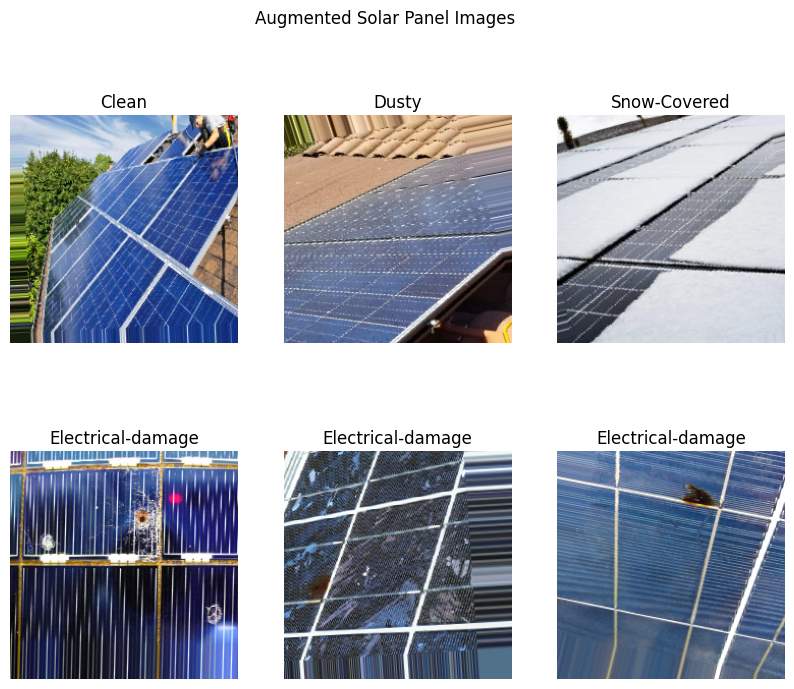

In [29]:
plt.figure(figsize=(10,8))


for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i])

    plt.title(
        list(train_data.class_indices.keys())[
            np.argmax(labels[i])
        ]
    )

    plt.axis("off")


plt.suptitle(
    "Augmented Solar Panel Images"
)

plt.show()

## MobileNetV2 Transfer Learning Model Building

In [31]:
# Load MobileNetV2 Base Model

base_model = MobileNetV2(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)

)

In [32]:
# Freeze Pretrained Layers

base_model.trainable = False

In [34]:
# Verify Frozen Layers

print(
    "Total layers:",
    len(base_model.layers)
)


print(
    "Trainable layers:",
    sum(
        layer.trainable 
        for layer in base_model.layers
    )
)

Total layers: 154
Trainable layers: 0


In [33]:
# Check Trainable Layers

print(
    "Total layers:",
    len(base_model.layers)
)


print(
    "Trainable:",
    sum(
        [layer.trainable for layer in base_model.layers]
    )
)

Total layers: 154
Trainable: 0


In [35]:
# Add Classification Head

x = base_model.output


x = GlobalAveragePooling2D()(x)


x = Dense(
    128,
    activation="relu"
)(x)


x = Dropout(
    0.3
)(x)


output = Dense(
    6,
    activation="softmax"
)(x)

In [36]:
# Create Final Model

model = Model(

    inputs=base_model.input,

    outputs=output

)

In [37]:
# Compile Model

model.compile(

    optimizer=Adam(
        learning_rate=0.0001
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)

In [38]:
# Check Model Summary

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [39]:
# Model Compilation Check
model.optimizer

In [41]:
model.loss

'categorical_crossentropy'

## Model Training

In [42]:
# Create Callbacks

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [43]:
# Early Stopping

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

In [44]:
# Model Checkpoint

checkpoint = ModelCheckpoint(

    "solarguard_mobilenetv2.keras",

    monitor="val_accuracy",

    save_best_only=True,

    mode="max"

)

In [45]:
# Train Model

history = model.fit(

    train_data,

    validation_data=validation_data,

    epochs=20,

    callbacks=[
        early_stop,
        checkpoint
    ]

)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 428ms/step - accuracy: 0.2335 - loss: 1.9774 - val_accuracy: 0.3793 - val_loss: 1.6202
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 351ms/step - accuracy: 0.3671 - loss: 1.6435 - val_accuracy: 0.4770 - val_loss: 1.4157
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 357ms/step - accuracy: 0.4459 - loss: 1.4633 - val_accuracy: 0.5632 - val_loss: 1.2639
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 361ms/step - accuracy: 0.4909 - loss: 1.3735 - val_accuracy: 0.5747 - val_loss: 1.1948
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 370ms/step - accuracy: 0.5612 - loss: 1.2343 - val_accuracy: 0.6207 - val_loss: 1.1082
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 343ms/step - accuracy: 0.5598 - loss: 1.1965 - val_accuracy: 0.6724 - val_loss: 1.0073
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 345ms/step - accuracy: 0.6104 - loss: 1.0914 - val_accuracy: 0.6149 - val_loss: 1.0505
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 344ms/step - accuracy: 0.6357 - loss: 1.0822 - val_accuracy: 0

In [46]:
ModelCheckpoint(
"solarguard_mobilenetv2.keras",
save_best_only=True
)

In [47]:
os.path.exists("solarguard_mobilenetv2.keras")

True

In [48]:
os.path.getsize("solarguard_mobilenetv2.keras") / (1024*1024)

11.06246280670166

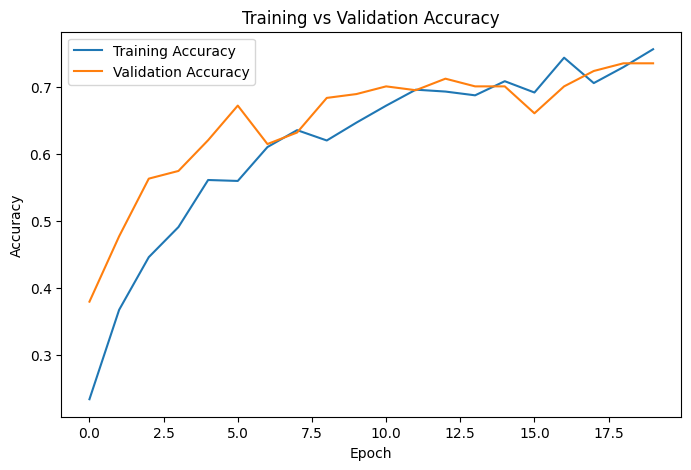

In [49]:
# Accuracy Curve

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

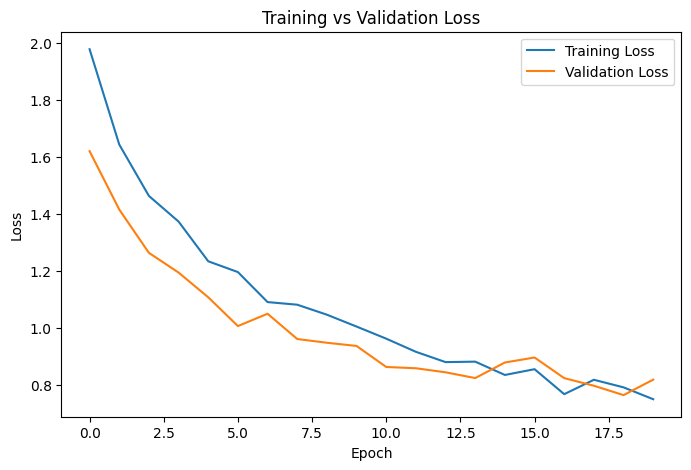

In [50]:
# Loss Curve

plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

## Model Evaluation

In [51]:
# Load Best Saved Model

from tensorflow.keras.models import load_model

best_model = load_model(
    "solarguard_mobilenetv2.keras"
)

In [52]:
# Generate Predictions

predictions = best_model.predict(
    validation_data
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 319ms/step


In [53]:
# Convert Predictions to Class Labels

y_pred = np.argmax(
    predictions,
    axis=1
)

In [54]:
y_true = validation_data.classes

In [55]:
print(y_pred.shape)

print(y_true.shape)

(174,)
(174,)


In [56]:
# Get Class Names

class_names = list(
    validation_data.class_indices.keys()
)

class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

In [57]:
# Classification Report

report = classification_report(

    y_true,

    y_pred,

    target_names=class_names

)

print(report)

                   precision    recall  f1-score   support

        Bird-drop       0.68      0.68      0.68        41
            Clean       0.79      0.79      0.79        38
            Dusty       0.68      0.74      0.71        38
Electrical-damage       0.85      0.85      0.85        20
  Physical-Damage       1.00      0.69      0.82        13
     Snow-Covered       0.84      0.88      0.86        24

         accuracy                           0.76       174
        macro avg       0.81      0.77      0.78       174
     weighted avg       0.77      0.76      0.77       174



In [58]:
# Confusion Matrix

cm = confusion_matrix(

    y_true,

    y_pred

)


cm

array([[28,  2,  9,  2,  0,  0],
       [ 4, 30,  4,  0,  0,  0],
       [ 3,  2, 28,  1,  0,  4],
       [ 0,  3,  0, 17,  0,  0],
       [ 4,  0,  0,  0,  9,  0],
       [ 2,  1,  0,  0,  0, 21]])

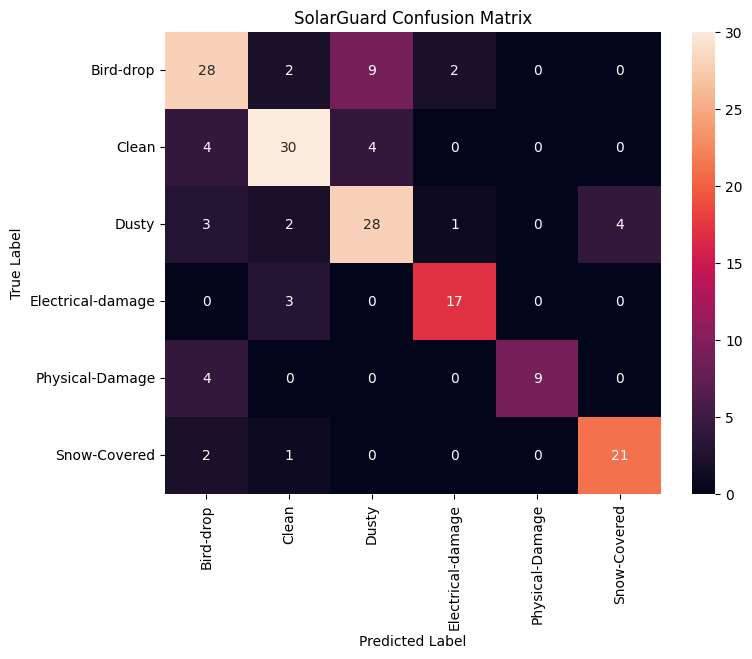

In [59]:
# Visualize Confusion Matrix

plt.figure(figsize=(8,6))


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=class_names,

    yticklabels=class_names

)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "True Label"
)


plt.title(
    "SolarGuard Confusion Matrix"
)


plt.show()

In [60]:
# Overall Accuracy

from sklearn.metrics import accuracy_score


accuracy = accuracy_score(

    y_true,

    y_pred

)


print(
    "Validation Accuracy:",
    accuracy
)

Validation Accuracy: 0.764367816091954


The MobileNetV2 transfer learning model achieved a validation accuracy of 76.43%. Among the six solar panel conditions, Snow-Covered and Electrical-Damage classes achieved the highest classification performance due to their distinct visual patterns. Bird-Drop and Dusty classes showed some misclassification because both contain similar surface obstruction characteristics. The confusion matrix indicates that the model successfully distinguishes major defect categories while minor surface variations remain challenging.

In [61]:
print(os.path.exists("solarguard_mobilenetv2.keras"))

True
